In [1]:
import pandas as pd
import numpy as np

import os
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import spearmanr, pearsonr, ttest_ind, percentileofscore
import itertools

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

In [2]:
AA_LIST = list("ACDEFGHIKLMNPQRSTVWYO-")
N_AA = len(AA_LIST)
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}
idx_to_aa = {v: k for k, v in aa_to_idx.items()}

def sum_norm(data):
    arr_sum = np.sum(data)
    return data/arr_sum

def min_max_norm(data):
    data_min = np.min(data)
    data_max = np.max(data)
    normalized_data = (data - data_min) / (data_max - data_min)
    return normalized_data

def clipping_max_norm(data, cutoff=99):
    upper_limit = np.percentile(data, cutoff)
    clipped_matrix = np.clip(data, a_min=0, a_max=upper_limit)
    # Normalize to [0, 1]
    normalized_data = clipped_matrix / upper_limit
    return normalized_data

def magnitude_norm(data, data_min=0):
    data_max = np.max(np.abs(data))
    normalized_data = (data - data_min) / (data_max - data_min)
    return normalized_data

def predict_ok(predict_df, selected_seqno):
    pred = predict_df.loc[predict_df["Seq_no"] == selected_seqno, "Prediction"].values[0]
    true = predict_df.loc[predict_df["Seq_no"] == selected_seqno, "Label"].values[0]
    pred_0 = float(pred.split()[1].split(",")[0])
    pred_1 = float(pred.split()[3].split("}")[0])
    pred_class = 0
    if pred_1 > pred_0:
        pred_class = 1
    if pred_class == true:
        return True
    else:
        return False

def get_res_talk(attn_all_layers):
    aa_attn_all_layers = attn_all_layers[:,:,1:-1,1:-1]
    cls_attn_all_layers = attn_all_layers[:,:,0,1:-1]
    L_SEQ = aa_attn_all_layers.shape[2]

    weighted_attn_all_layers = np.zeros([cls_attn_all_layers.shape[0], cls_attn_all_layers.shape[1], L_SEQ, L_SEQ])
    for n_layer in range(cls_attn_all_layers.shape[0]):
        for n_head in range(cls_attn_all_layers.shape[1]):
            norm_cls = min_max_norm(cls_attn_all_layers[n_layer][n_head])
            # by cls-to-i -> norm_cls.reshape(len(norm_cls),1)
            # by cls-to-j -> norm_cls
            weighted_attn_all_layers[n_layer][n_head] = aa_attn_all_layers[n_layer][n_head] * norm_cls.reshape(len(norm_cls),1) #* norm_cls * aa_attn_all_layers[n_layer][n_head].T
    
    sum_weighted_attn = np.sum(weighted_attn_all_layers, axis=(0,1))
    return sum_weighted_attn

In [3]:
selected_models = ["rep_5", "rep_6", "rep_7", "rep_9", "rep_10"]
root_dir = "/Users/fahsainakarin/Library/CloudStorage/OneDrive-UCB-O365/Lab/Rotations/Kayla/ML/communication"
attr_dir = "attribution_maps"
attn_dir = "attention_maps"
data_dir = "data"
task_type = "classification"

info_df = pd.read_csv(os.path.join(root_dir, data_dir, "input_info_VRC01_IC80.csv"))

resno_df = pd.read_csv(os.path.join(root_dir, data_dir, "selected_residues_IC80.csv"))
resno_array = resno_df["ResLabel"].values

vrc01_footprint = set([97, 123, 124, 198, 276, 278, 279, 280, 281, 282, 365, 366, 367, 368, 371, 427, 428, 429, 430, 455, 456, 457, 458, 459, 460, 461, 463, 465, 466, 467, 469, 472, 473, 474, 476])
vrc01_covary = set([46, 132, 138, 144, 150, 179, 181, 186, 190, 290, 321, 328, 354, 389, 394, 396, 397, 406])
vrc01_pngs = set([156, 157, 158, 229, 230, 231, 234, 235, 236, 616, 617, 618, 824, 825, 826])

vrc01_contact_residues = list(vrc01_footprint | vrc01_covary | vrc01_pngs)
vrc01_contact_residues = [str(_) for _ in vrc01_contact_residues]
vrc01_footprint_residues = [str(_) for _ in vrc01_footprint]

In [285]:
seq_no = [2166] #[2167]

data_df = info_df.loc[info_df['Seq_no'].isin(seq_no)]
aligned_sequences = np.array([list(seq) for seq in data_df['Sequence']])

N_MODEL = len(selected_models)
N_SEQ, L_SEQ = len(seq_no), 209

all_attr_array_0 = np.zeros([N_MODEL, N_SEQ, L_SEQ])
all_attr_array_1 = np.zeros([N_MODEL, N_SEQ, L_SEQ])
attn_scalar_array = np.zeros((N_MODEL, N_SEQ, L_SEQ, L_SEQ))
cls_attn_scalar_array =  np.zeros([N_MODEL, N_SEQ, L_SEQ])

for n, model_name in enumerate(selected_models):
    for i, no in enumerate(seq_no):
        attr_0 = np.load(os.path.join(root_dir, attr_dir, model_name, str(no)+"_attribution_ig_class_0.npy"))
        all_attr_array_0[n,i] = magnitude_norm(attr_0)

        attr_1 = np.load(os.path.join(root_dir, attr_dir, model_name, str(no)+"_attribution_ig_class_1.npy"))
        all_attr_array_1[n,i] = magnitude_norm(attr_1)

attr_1_array = all_attr_array_1.copy()
attr_0_array = all_attr_array_0.copy()

pos_conflict_mask = (attr_0_array > 0) & (attr_1_array > 0)
neg_conflict_mask = (attr_0_array < 0) & (attr_1_array < 0)
conflict_mask = (pos_conflict_mask | neg_conflict_mask)
align_mask = ~conflict_mask

abs_attr_score_array = (np.abs(attr_0_array) + np.abs(attr_1_array)) / 2
abs_attr_score_array[conflict_mask] = 0
attr_score_array = abs_attr_score_array.copy()
# assign signs by class 1 attribution from each model
attr_score_array[(align_mask & (attr_1_array < 0))] *= -1

In [286]:
all_sum_attn_attr = np.zeros([N_MODEL, N_SEQ, L_SEQ, L_SEQ])
for n, model_name in enumerate(selected_models):
    model_sum_attn_attr = np.zeros([N_SEQ, L_SEQ, L_SEQ])
    for i, no in enumerate(seq_no):
        attn_all_layers = np.load(os.path.join(root_dir, attn_dir, model_name, str(no)+"_attentions_raw.npy"))
        sum_attn_attr = get_res_talk(attn_all_layers)
        model_sum_attn_attr[i] = sum_attn_attr
    all_sum_attn_attr[n] = clipping_max_norm(model_sum_attn_attr) #min_max_norm(model_sum_attn_attr)

influential = np.transpose(all_sum_attn_attr[:,i], axes=(0,2,1))
vulnerability = all_sum_attn_attr[:,i].copy()

mean_influential = np.mean(influential, axis=0)
mean_vulnerability = np.mean(vulnerability, axis=0)

print(pearsonr(mean_influential.flatten(), mean_vulnerability.flatten()))
print(spearmanr(mean_influential.flatten(), mean_vulnerability.flatten()))

PearsonRResult(statistic=0.8533824355442139, pvalue=0.0)
SignificanceResult(statistic=0.6715485204531343, pvalue=0.0)


In [287]:
global_sig_attr = pd.read_csv(os.path.join(root_dir, data_dir, "sig_attr_with_attn.csv"))

global_sig_attr_negative = global_sig_attr[global_sig_attr["AA_mean_score_attr"] < 0]
global_sig_feature_negative = np.array(global_sig_attr_negative["ResLabel"] + "_" + global_sig_attr_negative["AA"])

global_sig_attr_positive = global_sig_attr[global_sig_attr["AA_mean_score_attr"] > 0]
global_sig_feature_positive = np.array(global_sig_attr_positive["ResLabel"] + "_" + global_sig_attr_positive["AA"])

In [288]:
i = 0
known_resistant = np.where(resno_array == '280')[0]
resname = resno_array + "_" + aligned_sequences[i]
sig_mask = np.isin(resname, global_sig_feature_positive) | np.isin(resname, global_sig_feature_negative) | (resname == resname[known_resistant])
vrc01_mask = np.isin(resno_array[sig_mask], vrc01_footprint_residues) #vrc01_footprint_residues

x_labels = resname[sig_mask][vrc01_mask]

selected_influential = mean_influential[sig_mask][vrc01_mask]
selected_vulnerability = mean_vulnerability[sig_mask][vrc01_mask]

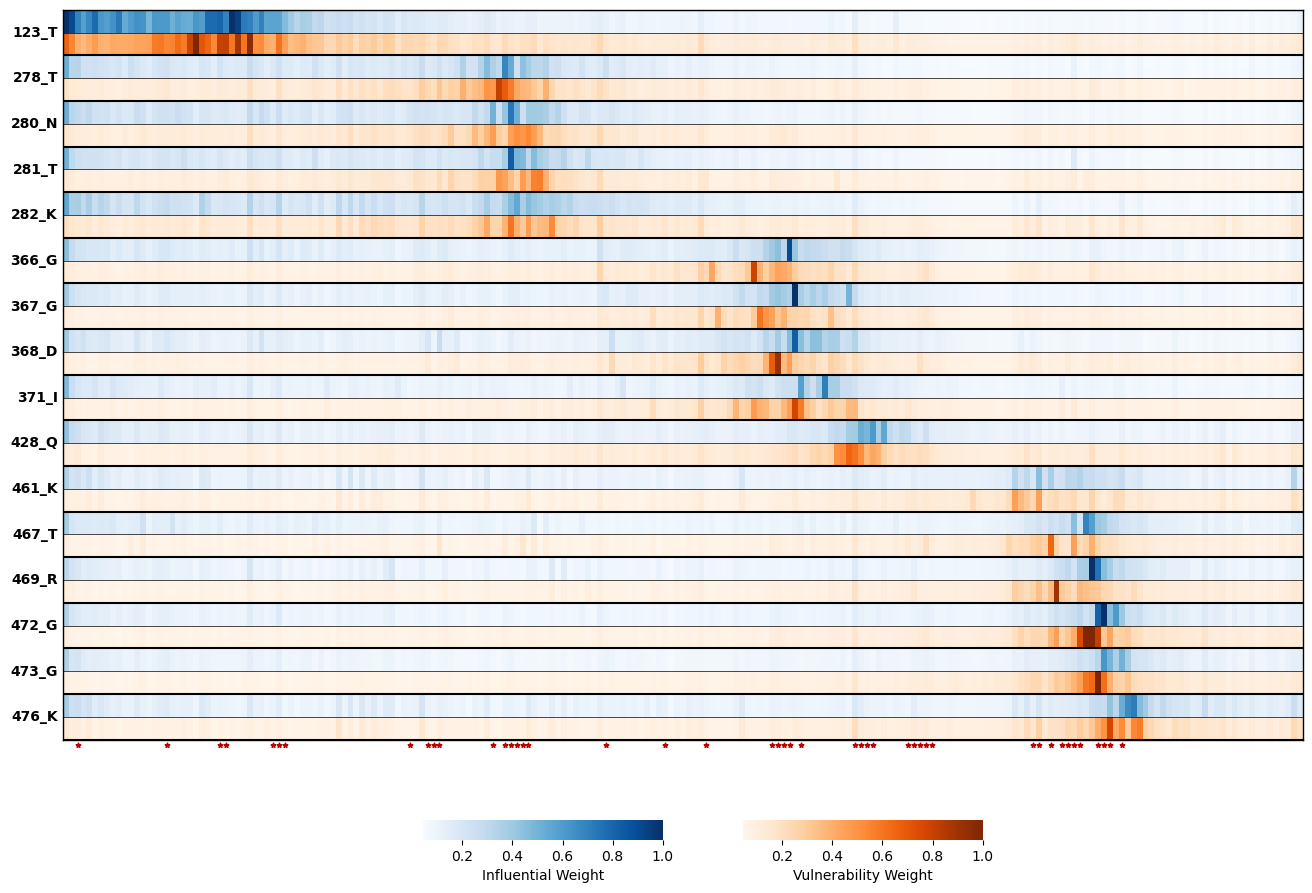

In [289]:
combined_data = np.zeros((len(x_labels) * 2, L_SEQ))
combined_data[0::2] = selected_influential
combined_data[1::2] = selected_vulnerability

# Create Masks for Overlay Plotting
# mask_inf will hide Vulnerability rows (True where we DON'T want to see Influence data)
mask_inf = np.ones_like(combined_data, dtype=bool)
mask_inf[0::2] = False 

# mask_vul will hide Influence rows
mask_vul = np.ones_like(combined_data, dtype=bool)
mask_vul[1::2] = False

# Create Interleaved Labels
interleaved_labels = []
for label in x_labels:
    interleaved_labels.extend([f"{label} (Inf)", f"{label} (Vul)"])

# Create DataFrame
df_heatmap = pd.DataFrame(
    combined_data,
    index=interleaved_labels,
    columns=np.arange(1, L_SEQ + 1)
)

# --- 3. Plotting Logic (Template Style) ---
fig, ax = plt.subplots(figsize=(16, 10))

# Define Colorbar Axes manually to place them side-by-side at the bottom
cbar_ax1 = fig.add_axes([0.35, 0.05, 0.15, 0.02]) # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.55, 0.05, 0.15, 0.02])

# Plot 1: Influence (Blues) - Masking out Vulnerability rows
sns.heatmap(
    df_heatmap,
    mask=mask_inf, # Hide Vulnerability rows
    ax=ax,
    cmap="Blues",
    annot=False,
    cbar_ax=cbar_ax1,
    cbar_kws={'label': 'Influential Weight', 'orientation': 'horizontal'}
)

# Plot 2: Vulnerability (Reds) - Masking out Influence rows
sns.heatmap(
    df_heatmap,
    mask=mask_vul, # Hide Influence rows
    ax=ax,
    cmap="Oranges",
    annot=False,
    cbar_ax=cbar_ax2,
    cbar_kws={'label': 'Vulnerability Weight', 'orientation': 'horizontal'}
)

# --- Customizing Borders and Separators ---
# 1. Add border around the entire heatmap
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

# 2. Add horizontal separators
for i in range(df_heatmap.shape[0] + 1):
    if i % 2 == 0:
        # Thicker line between different residues
        ax.axhline(i, color='black', linewidth=1.5)
    else:
        # Thinner/Dashed line between Influence and Vulnerability of the same residue
        ax.axhline(i, color='black', linewidth=0.5, linestyle='-')

# --- Highlight Logic (Red Dots) ---
# Calculate indices: "x is in np.where(np.isin(resno_array, vrc01_contact_residues))[0] + 1"
hl_idx = np.where(np.isin(resno_array, vrc01_contact_residues))[0] + 1
x_coords = hl_idx - 0.5
y_coords = np.full(len(x_coords), df_heatmap.shape[0] + 0.25) 

ax.scatter(
    x_coords, 
    y_coords, 
    color='#C00000',
    s=12, 
    marker='*', 
    clip_on=False,
    label='VRC01 Contact Site'
)

# --- Styling ---
ax.set_xticks([])

# Center tick between 2 rows
ax.set_yticks(np.arange(0.5, df_heatmap.shape[0], 2) + 0.5) 
ax.set_yticklabels(x_labels, rotation=0, fontsize=10, fontweight='bold')
ax.tick_params(axis='y', length=0) # Hide tick marks

# Adjust main plot layout to make room for colorbars
plt.subplots_adjust(bottom=0.15)
plt.savefig(f"vrc01_influential_vulnerability_heatmap_{seq_no[0]}.png", dpi=300, bbox_inches='tight')
plt.show()

In [290]:
mean_attr_score_array = np.mean(attr_score_array, axis=0)
sd_attr_score_array = np.std(attr_score_array, axis=0)

for i, no in enumerate(data_df['Seq_no']):
    print(data_df["Seq_name"].iloc[i], data_df["IC80"].iloc[i], data_df["Label"].iloc[i])
    print("Attribution")
    print(np.sum(mean_attr_score_array[i]))
    cutoff = 0 #np.percentile(np.abs(mean_attr_score_array[i]), 83)
    mask = np.abs(mean_attr_score_array[i]) > cutoff
    print(resno_array[mask]+aligned_sequences[i][mask])
    print(np.sum(mean_attr_score_array[i, mask]))

    pos_line = np.percentile(mean_attr_score_array[i][mean_attr_score_array[i] > 0], 75)
    neg_line = np.percentile(mean_attr_score_array[i][mean_attr_score_array[i] < 0], 25)

C.ZM.2018.V703_0790_190_RE_E5G1S.ON890993 13.0163 0
Attribution
-7.734576109601495
['44V' '45W' '46K' '47E' '49K' '58A' '82Q' '83E' '84I' '88O' '89V' '90T'
 '91E' '92N' '93F' '94N' '96W' '97E' '98N' '99N' '102N' '105H' '109I'
 '117K' '121K' '122L' '123T' '124P' '127V' '134A' '135O' '136Y' '137S'
 '139D' '140A' '156O' '157C' '158T' '160O' '161A' '162S' '162A-' '163T'
 '164E' '165I' '165A-' '166K' '167D' '168K' '168A-' '169K' '170Y' '171K'
 '172Q' '173R' '192R' '193L' '197O' '198S' '199S' '207K' '230D' '234O'
 '236T' '237G' '238P' '240H' '241O' '245V' '246Q' '262O' '275K' '276O'
 '277L' '278T' '279D' '280N' '281T' '282K' '283T' '301O' '303T' '304R'
 '306S' '308R' '309I' '315Q' '315A-' '315B-' '316T' '318F' '321G' '322D'
 '323I' '323AI' '324G' '325N' '325A-' '325B-' '326I' '327R' '328E' '329A'
 '330H' '332O' '334S' '352H' '353F' '354P' '354A-' '354B-' '354C-' '354H-'
 '355-' '357K' '362O' '364S' '364A-' '364B-' '365S' '366G' '367G' '368D'
 '370E' '371I' '392O' '415T' '415A-' '415B-' '416I

In [292]:
i = 0
attr_selected_res_idx = np.where(np.isin(resname, resname[sig_mask][vrc01_mask]))[0]

results = {
    "Residue": [],
    
    # Attribution Metrics (For Plot 1)
    "Attr_Mean": [], "Attr_SD": [],

    # Influence Metrics (For Plot 2)
    "Inf_Net_Mean": [], "Inf_Net_SD": [],
    "Inf_Pos_Mean": [], "Inf_Pos_SD": [],
    "Inf_Neg_Mean": [], "Inf_Neg_SD": [],
    
    # Vulnerability Metrics (For Plot 2)
    "Vul_Net_Mean": [], "Vul_Net_SD": [],
    "Vul_Pos_Mean": [], "Vul_Pos_SD": [],
    "Vul_Neg_Mean": [], "Vul_Neg_SD": [],
}

# --- Calculation Loop ---
for resno_pos in attr_selected_res_idx:
    res_label = f"{resno_array[resno_pos]}_{aligned_sequences[i][resno_pos]}"
    results["Residue"].append(res_label)
    print(f"Processing {res_label}...")

    # Get Attribution scores for sequence i across all models: (N_MODELS, L_SEQ)
    # We use these to weight the attention
    attrs = attr_score_array[:, i, :]
    
    # Store Attribution stats for this residue (for the top plot)
    res_attrs_val = attrs[:, resno_pos]
    results["Attr_Mean"].append(np.mean(res_attrs_val))
    results["Attr_SD"].append(np.std(res_attrs_val))

    # ---------------------------------------------------------
    # 1. Goodness of Influence (Outgoing Impact)
    # ---------------------------------------------------------
    # Shape: (N_MODELS, L_SEQ). Attention from resno_pos to all other residues j
    influence_map = influential[:, resno_pos, :] 

    # A. Net Influence
    # Weight attention by raw attribution
    net_influence_dist = np.sum(influence_map * attrs, axis=1) # Sum over L_SEQ -> (N_MODELS,)
    results["Inf_Net_Mean"].append(np.mean(net_influence_dist))
    results["Inf_Net_SD"].append(np.std(net_influence_dist))

    # B. Positive Influence (Supporting Features)
    # Mask: Keep only positive attributions, zero out negatives
    pos_attrs = np.clip(attrs, 0, None)
    norm_pos_attrs = np.divide(pos_attrs, np.sum(pos_attrs, axis=1, keepdims=True))
    pos_influence_dist = np.sum(influence_map * norm_pos_attrs, axis=1)
    results["Inf_Pos_Mean"].append(np.mean(pos_influence_dist))
    results["Inf_Pos_SD"].append(np.std(pos_influence_dist))

    # C. Negative Influence (Opposing/Resistance Features)
    # Mask: Keep only negative attributions, zero out positives
    neg_attrs = np.clip(attrs, None, 0)
    norm_neg_attrs = np.divide(neg_attrs, np.sum(neg_attrs, axis=1, keepdims=True))
    neg_influence_dist = np.sum(influence_map * norm_neg_attrs, axis=1)
    results["Inf_Neg_Mean"].append(np.mean(neg_influence_dist))
    results["Inf_Neg_SD"].append(np.std(neg_influence_dist))

    # ---------------------------------------------------------
    # 2. Goodness of Vulnerability (Incoming Sensitivity)
    # ---------------------------------------------------------
    # Shape: (N_MODELS, L_SEQ). Attention from all other residues j to resno_pos
    vulnerable_map = vulnerability[:, resno_pos, :]

    # A. Net Vulnerability
    net_vulnerability_dist = np.sum(vulnerable_map * attrs, axis=1)
    results["Vul_Net_Mean"].append(np.mean(net_vulnerability_dist))
    results["Vul_Net_SD"].append(np.std(net_vulnerability_dist))

    # B. Positive Vulnerability
    pos_vulnerability_dist = np.sum(vulnerable_map * norm_pos_attrs, axis=1)
    results["Vul_Pos_Mean"].append(np.mean(pos_vulnerability_dist))
    results["Vul_Pos_SD"].append(np.std(pos_vulnerability_dist))

    # C. Negative Vulnerability
    neg_vulnerability_dist = np.sum(vulnerable_map * norm_neg_attrs, axis=1)
    results["Vul_Neg_Mean"].append(np.mean(neg_vulnerability_dist))
    results["Vul_Neg_SD"].append(np.std(neg_vulnerability_dist))

print("--- Calculation Complete ---")

Processing 123_T...
Processing 278_T...
Processing 280_N...
Processing 281_T...
Processing 282_K...
Processing 366_G...
Processing 367_G...
Processing 368_D...
Processing 371_I...
Processing 428_Q...
Processing 461_K...
Processing 467_T...
Processing 469_R...
Processing 472_G...
Processing 473_G...
Processing 476_K...
--- Calculation Complete ---
